<a href="https://colab.research.google.com/github/nehareddyg261-collab/Machine-learning-1/blob/main/Loan_risk_Code_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
df.shape

(32581, 12)

Running in Google Colab — please upload credit_risk_dataset.csv


Saving credit_risk_dataset.csv.zip to credit_risk_dataset.csv (1).zip
Loaded 32581 rows, 12 columns


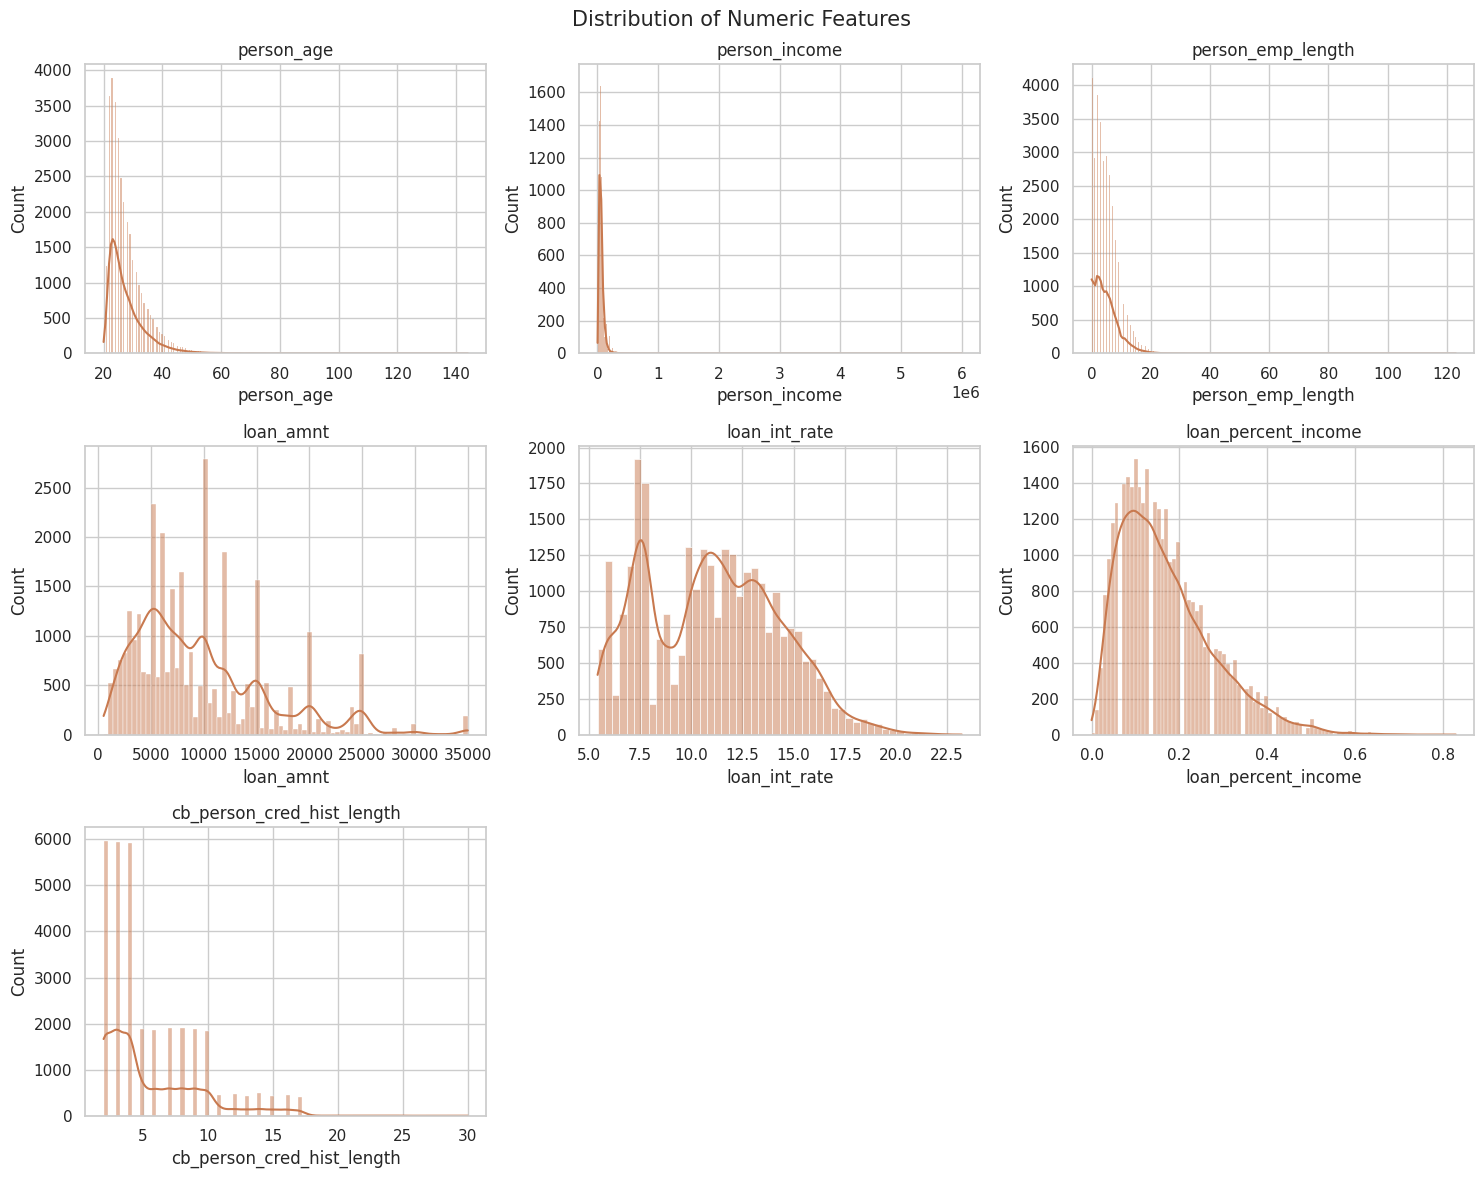

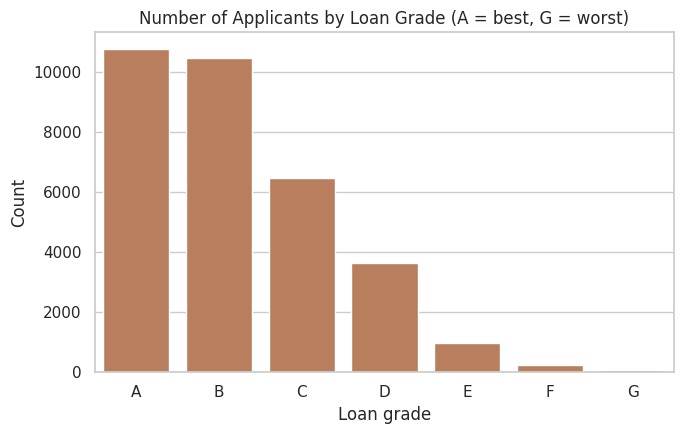

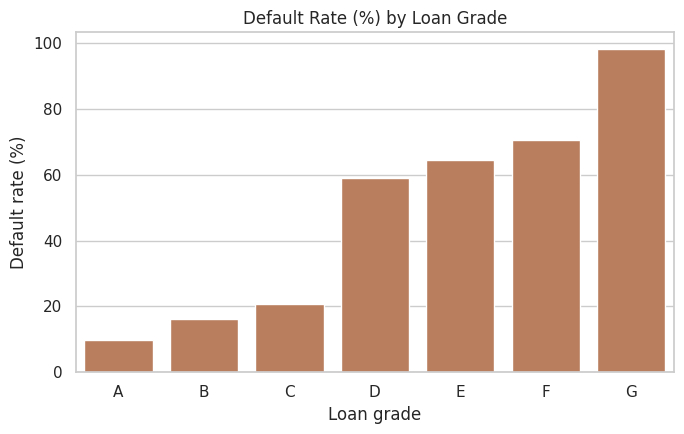

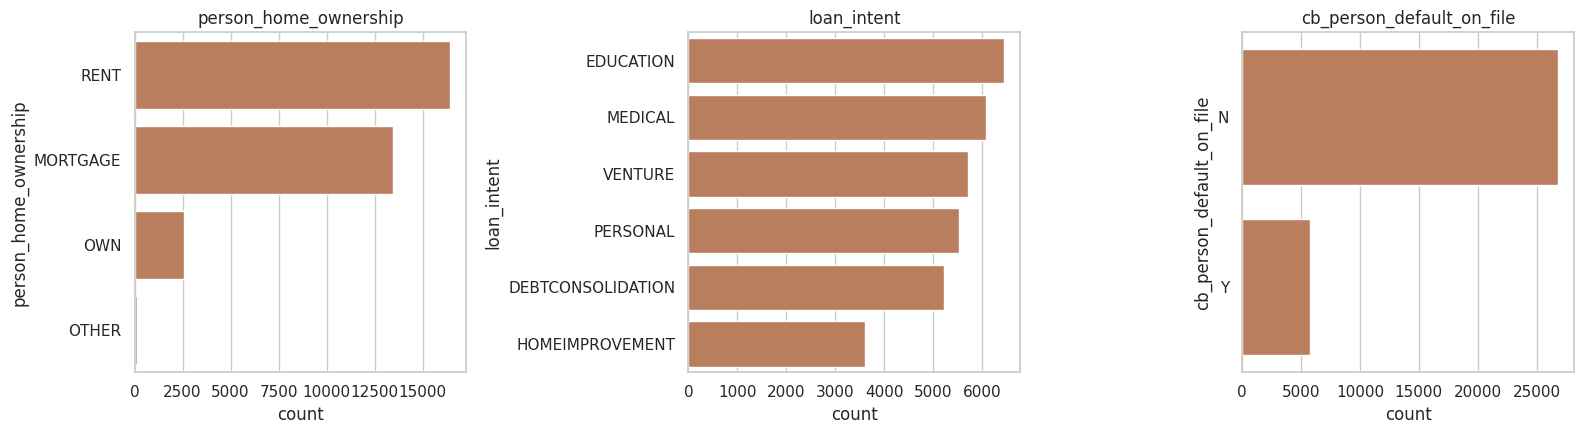

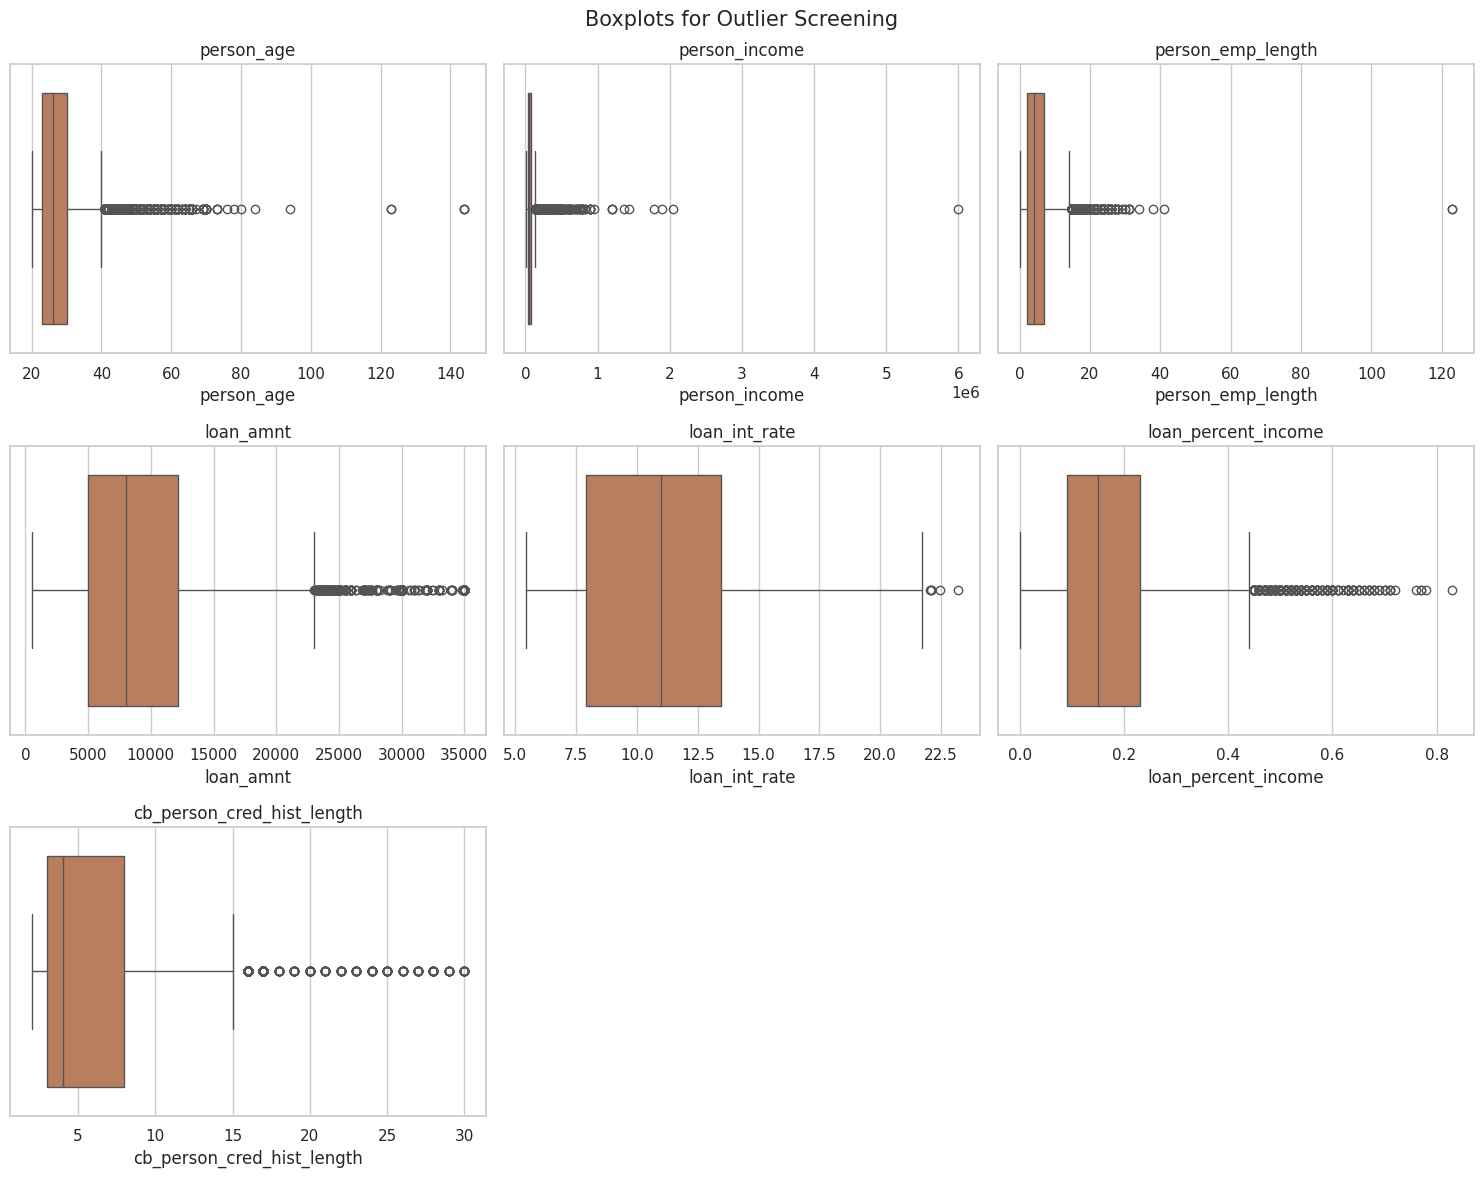

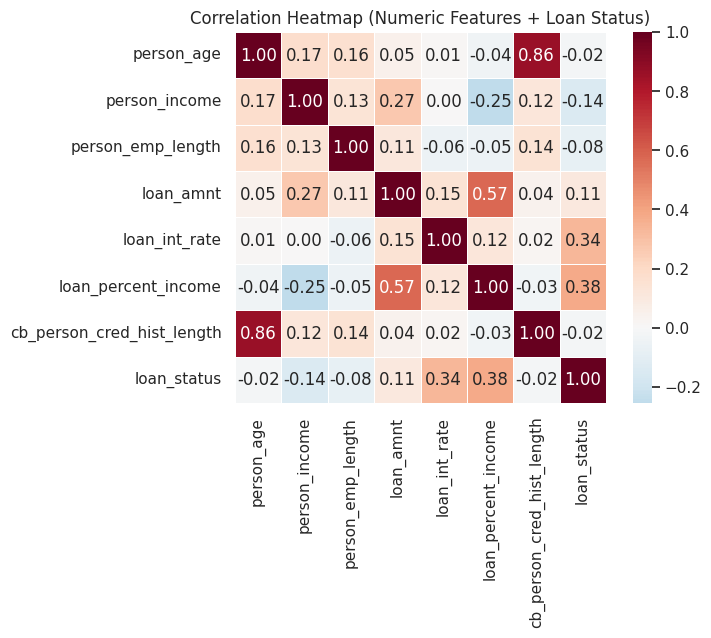

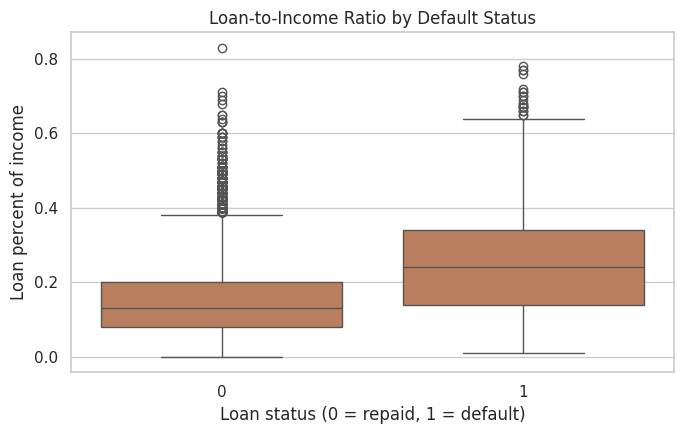

Done — all charts displayed.


In [1]:
# -*- coding: utf-8 -*-
"""CredictCardFraud

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1SJql3WRi0rT8g4YOlf1x1FAaY23JGovU
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------------------
# 0. Load the dataset
# ----------------------------------------------------------------------
# Option A — Google Colab: upload the CSV manually
try:
    import google.colab  # noqa: F401
    from google.colab import files
    print("Running in Google Colab — please upload credit_risk_dataset.csv")
    uploaded = files.upload()
    csv_path = list(uploaded.keys())[0]
except ImportError:
    # Option B — VS Code / local: put the CSV in the same folder as this script,
    # or change the path below.
    csv_path = "credit_risk_dataset.csv"

df = pd.read_csv(csv_path)
print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns")

sns.set_theme(style="whitegrid")
PALETTE = "#C8794F"  # single accent color used across charts

NUMERIC_COLS = [
    "person_age", "person_income", "person_emp_length", "loan_amnt",
    "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length",
]

# ----------------------------------------------------------------------
# 1. Histograms — distribution of each numeric feature
# ----------------------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(NUMERIC_COLS):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color=PALETTE)
    axes[i].set_title(col)
for j in range(len(NUMERIC_COLS), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle("Distribution of Numeric Features", fontsize=15)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# 2. Bar chart — count of applicants per loan grade (multi-class target)
# ----------------------------------------------------------------------
plt.figure(figsize=(7, 4.5))
order = sorted(df["loan_grade"].unique())
sns.countplot(x="loan_grade", data=df, order=order, color=PALETTE)
plt.title("Number of Applicants by Loan Grade (A = best, G = worst)")
plt.xlabel("Loan grade")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# 3. Bar chart — default rate (%) by loan grade
# ----------------------------------------------------------------------
grade_default = df.groupby("loan_grade")["loan_status"].mean().sort_index() * 100
plt.figure(figsize=(7, 4.5))
sns.barplot(x=grade_default.index, y=grade_default.values, color=PALETTE)
plt.title("Default Rate (%) by Loan Grade")
plt.xlabel("Loan grade")
plt.ylabel("Default rate (%)")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# 4. Bar charts — other categorical features
# ----------------------------------------------------------------------
CATEGORICAL_COLS = ["person_home_ownership", "loan_intent", "cb_person_default_on_file"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for i, col in enumerate(CATEGORICAL_COLS):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=axes[i], color=PALETTE)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# 5. Boxplots — visually spot outliers in numeric features
# ----------------------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(NUMERIC_COLS):
    sns.boxplot(x=df[col], ax=axes[i], color=PALETTE)
    axes[i].set_title(col)
for j in range(len(NUMERIC_COLS), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle("Boxplots for Outlier Screening", fontsize=15)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# 6. Correlation heatmap
# ----------------------------------------------------------------------
corr = df[NUMERIC_COLS + ["loan_status"]].corr(numeric_only=True)
plt.figure(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5)
plt.title("Correlation Heatmap (Numeric Features + Loan Status)")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# 7. Boxplot — a numeric feature split by binary default status
# ----------------------------------------------------------------------
plt.figure(figsize=(7, 4.5))
sns.boxplot(x="loan_status", y="loan_percent_income", data=df, color=PALETTE)
plt.title("Loan-to-Income Ratio by Default Status")
plt.xlabel("Loan status (0 = repaid, 1 = default)")
plt.ylabel("Loan percent of income")
plt.tight_layout()
plt.show()

print("Done — all charts displayed.")